In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
import time 

In [2]:
#%%
def sigmoid(z):
    g = 1/(1+np.exp(-z))
    return g

In [3]:
#%%
def sigmoidGradient(z):
    g_prime = np.zeros(z.shape)
    a = sigmoid(z)
    g_prime = a*(1-a)
    return g_prime

In [4]:
#%%
def nnCostFunction(nn_paras,input_layer_size,hidden_layer_size,num_labels,
                                   X, y, Lambda):
    m = X.shape[0] # number of data samples in the dataset
    J = 0
    W_hi = nn_paras[:(input_layer_size+1)*hidden_layer_size].reshape(hidden_layer_size,input_layer_size+1)
    W_kh = nn_paras[(input_layer_size+1)*hidden_layer_size:].reshape(num_labels,(hidden_layer_size+1))
    X = np.concatenate((np.ones((m,1)),X),axis=1)
    n = X.shape[1]
    a1 = np.zeros((n,m))
    a2 = np.zeros((W_hi.shape[0]+1,m))
    a3 = np.zeros((num_labels,m))
    yk = np.zeros((num_labels,m))
    epsilon = 1e-15
    for ii in np.arange(m):
        a1[:,ii] = X[ii,:].T
        z2 = W_hi@a1[:,ii]
        a2[:,ii] = np.concatenate((np.array([1]),sigmoid(z2)))
        z3 = W_kh@a2[:,ii]
        a3[:,ii]= sigmoid(z3)
        h = a3[:,ii]
        yk[y[ii]-1,ii] = 1
        J += np.sum((-yk[:,ii]).T*np.log(h+epsilon)-(1-yk[:,ii]).T*np.log(1-h+epsilon))
    J = J/m
    b = np.sum(np.sum(W_hi[:,1:]**2))+np.sum(np.sum(W_kh[:,1:]**2))
    J += Lambda/(2*m)*b
    return J

In [10]:
#%%
def gradient(nn_paras,input_layer_size,hidden_layer_size,num_labels,
                                   X, y, Lambda):
    m = X.shape[0]
    J = 0;
    W_hi = nn_paras[:(input_layer_size+1)*hidden_layer_size].reshape(hidden_layer_size,input_layer_size+1)
    W_kh = nn_paras[(input_layer_size+1)*hidden_layer_size:].reshape(num_labels,(hidden_layer_size+1))
    W_hi_grad = np.zeros(W_hi.shape)
    W_kh_grad = np.zeros(W_kh.shape)
    X = np.concatenate((np.ones((m,1)),X),axis=1)
    n = X.shape[1]
    a1 = np.zeros((n,m))
    a2 = np.zeros((W_hi.shape[0]+1,m))
    a3 = np.zeros((num_labels,m))
    yk = np.zeros((num_labels,m))
    for ii in np.arange(m):
        a1[:,ii] = X[ii,:].T
        z2 = W_hi@a1[:,ii]
        a2[:,ii] = np.concatenate((np.array([1]),sigmoid(z2)))
        z3 = W_kh@a2[:,ii]
        a3[:,ii]= sigmoid(z3)
        h = a3[:,ii]
        yk[y[ii]-1,ii] = 1
        J += np.sum((-yk[:,ii]).T*np.log(h)-(1-yk[:,ii]).T*np.log(1-h))
    J = J/m
    b = np.sum(np.sum(W_hi[:,1:]**2))+np.sum(np.sum(W_kh[:,1:]**2))
    J += Lambda/(2*m)*b

    D1 = np.zeros(W_hi.shape)
    D2 = np.zeros(W_kh.shape)
    for ii in np.arange(m):
        d3 = a3[:,ii] - yk[:,ii]
        d2 = (W_kh.T@d3)*sigmoidGradient(np.concatenate((np.array([1]),(W_hi@a1[:,ii]).reshape(-1))))
        D2 += d3.reshape(num_labels,1)@(a2[:,ii].reshape(hidden_layer_size+1,1)).T
        D1 += d2[1:].reshape(hidden_layer_size,1)@(a1[:,ii].reshape(input_layer_size+1,1)).T
    D2[:,0] = 1/m*D2[:,0]
    D1[:,0] = 1/m*D1[:,0]
    
    D2[:,1:] = 1/m*D2[:,1:] + Lambda/m *W_kh[:,1:]
    D1[:,1:] = 1/m*D1[:,1:] + Lambda/m *W_hi[:,1:]
    W_hi_grad = D1;
    W_kh_grad = D2;
    grad = np.concatenate((W_hi_grad.reshape(-1),W_kh_grad.reshape(-1)),axis=0)
    return grad

In [8]:
#%%
def displayData(X,nCols):
    m,n = X.shape
    nRows = int(m/nCols)
    plt.figure(1,figsize=(6,10))
    for i in np.arange(m):
        plt.subplot(nRows,nCols,i+1)
        plt.imshow(X[i,:].reshape(20,20,order='F'),extent=[-1,1,-1,1]) 
        plt.axis('off')
        

In [9]:
#%%
def predict(w_hi,w_kh, X):
    
    m, n = X.shape
    NLabels, o = w_kh.shape

    # You need to return the following variables correctly 
    p = np.zeros((m))
    ah = sigmoid(np.concatenate((np.ones((m, 1)),X),axis=1)@w_hi.T)
    ak = sigmoid(np.concatenate((np.ones((m, 1)),ah),axis=1)@w_kh.T);
    for i in range(m):
        p[i] = np.where(ak[i,:]==np.max(ak[i,:]))[0][0]+1
    return p

In [6]:
#%%  
df = pd.read_csv('ex3data1.csv',header = None)
print(df.head())
#%%
X= np.array(df.loc[:,0:399].values)
y = np.array(df[400].values,ndmin=2).reshape(-1).T
m, n = X.shape
print(m,n)
print(y[500:505])

   0    1    2    3    4    5    6    7    8    9    ...  391  392  393  394  \
0    0    0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
1    0    0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
2    0    0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
3    0    0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
4    0    0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

   395  396  397  398  399  400  
0  0.0  0.0  0.0  0.0    0   10  
1  0.0  0.0  0.0  0.0    0   10  
2  0.0  0.0  0.0  0.0    0   10  
3  0.0  0.0  0.0  0.0    0   10  
4  0.0  0.0  0.0  0.0    0   10  

[5 rows x 401 columns]
5000 400
[1 1 1 1 1]


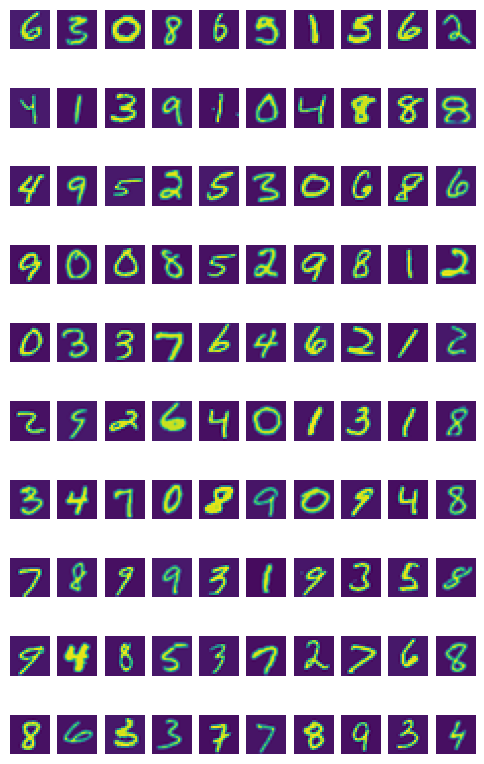

In [7]:
#%%
# randomly select 100 data points
randIndex = np.random.permutation(m)
sel = X[randIndex[0:100],:]
displayData(sel,10)

In [11]:
#%%
input_layer_size  = 400  # 20x20 Input Images of Digits
hidden_layer_size = 25   # 25 hidden units
num_labels = 10          # 10 labels, from 1 to 10 (note that we have mapped "0" to label 10)
#%%
Lambda =  3 # regularization parameter
W_hi = np.random.rand(hidden_layer_size,input_layer_size+1)
W_kh = np.random.rand(num_labels,hidden_layer_size+1)
nn_paras = np.concatenate((W_hi.flatten(), W_kh.flatten()))
sol_opt =  optimize.fmin_cg(nnCostFunction,nn_paras,fprime=gradient,
                                args=(input_layer_size,hidden_layer_size,
                                      num_labels,X,y.astype(int),Lambda),
                                maxiter=200,gtol=1e-5)
#%%
W_opt = sol_opt

W_hi = np.reshape(W_opt[:hidden_layer_size * (input_layer_size + 1)],
                 (hidden_layer_size, (input_layer_size + 1)))
W_kh = np.reshape(W_opt[( (hidden_layer_size * (input_layer_size + 1))):],
                 (num_labels, (hidden_layer_size + 1)))

         Current function value: 0.593927
         Iterations: 200
         Function evaluations: 411
         Gradient evaluations: 411


C:\Users\thein\anaconda3\Lib\site-packages\scipy\optimize\_optimize.py:1697: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, **opts)


In [12]:
p = predict(W_hi, W_kh, X)
accuracy = np.mean(1*(p==y))*100
print('\nTraining Set Accuracy: {:.2f}\n'.format(accuracy))


Training Set Accuracy: 97.36



		Target		Prediction
		1			1
		3			3
		5			5
		2			2
		6			6
		8			8
		0			0
		8			8
		5			5
		6			6
		4			4
		0			0
		6			6
		6			6
		2			2
		4			4
		9			9
		4			4
		6			6
		9			9
Confusion Matrix:
 [[491   2   2   1   2   1   0   1   0   0]
 [  3 484   1   5   1   0   1   2   1   2]
 [  2   5 473   0   7   1   6   4   2   0]
 [  2   1   0 486   1   3   0   1   6   0]
 [  0   3   4   1 488   1   0   2   1   0]
 [  2   0   0   0   1 494   0   1   0   2]
 [  4   3   0   2   1   0 484   0   4   2]
 [  3   2   1   0   2   1   0 490   1   0]
 [  2   0   5   2   1   0   5   1 481   3]
 [  0   0   0   0   0   2   0   1   0 497]]
Accuracy: 0.9736


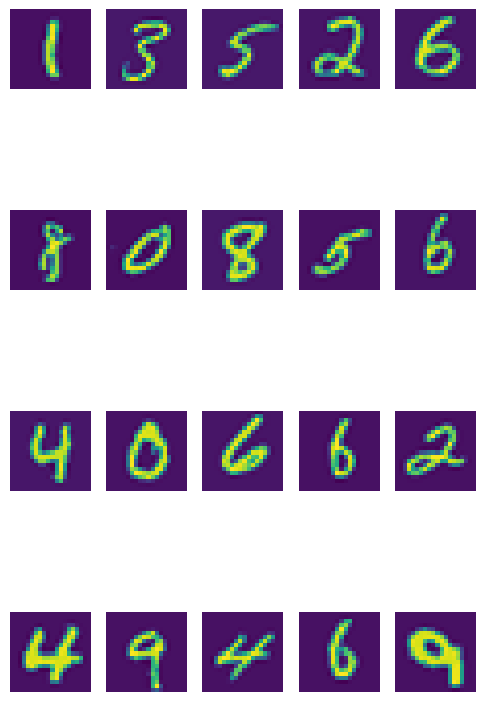

In [15]:
#%%
sel = np.random.permutation(m)
n = 20
sel = sel[0:n]
X_sel = X[sel,:]
displayData(X_sel,5)
p2 = predict(W_hi,W_kh, X_sel)
p2[np.where(p2==10)]=0
k = sel//500
k[np.where(k==10)]=0
print('\t\tTarget\t\tPrediction')
for i in np.arange(n):
    print('\t\t{:d}\t\t\t{:d}'.format(k[i],int(p2[i])))
#%%
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
    # Generate confusion matrix
conf_matrix = confusion_matrix(y, p)
print("Confusion Matrix:\n", conf_matrix)
#%%
accuracy = accuracy_score(y, p)
print("Accuracy:", accuracy)